In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

print( 'libraries loaded successfully')




libraries loaded successfully


In [65]:
from google.colab import files
uploaded = files.upload()

Saving yield_df[1].csv to yield_df[1] (3).csv


In [66]:
df = pd.read_csv('yield_df[1].csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (28242, 8)


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB


In [68]:
df.describe()

,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


In [69]:
print ('missing values per column:')
print(df.isnull().sum())

missing values per column:
Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


In [70]:
print(f"Unique crops: {df['Item'].nunique()}")
print(df['Item'].unique())
print(f"\nUnique countires: {df['Area'].nunique()}")
print(f"duplicates: {df.duplicated().sum()}")

Unique crops: 10
['Maize' 'Potatoes' 'Rice, paddy' 'Sorghum' 'Soybeans' 'Wheat' 'Cassava'
 'Sweet potatoes' 'Plantains and others' 'Yams']

Unique countires: 101
duplicates: 0


In [71]:
df = df.dropna()
if 'Unnamed: 0' in df.columns:
  df = df.drop(columns=['Unnamed: 0'])

print(f'clean dataset shape: {df.shape}')
df.head()

clean dataset shape: (28242, 7)


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


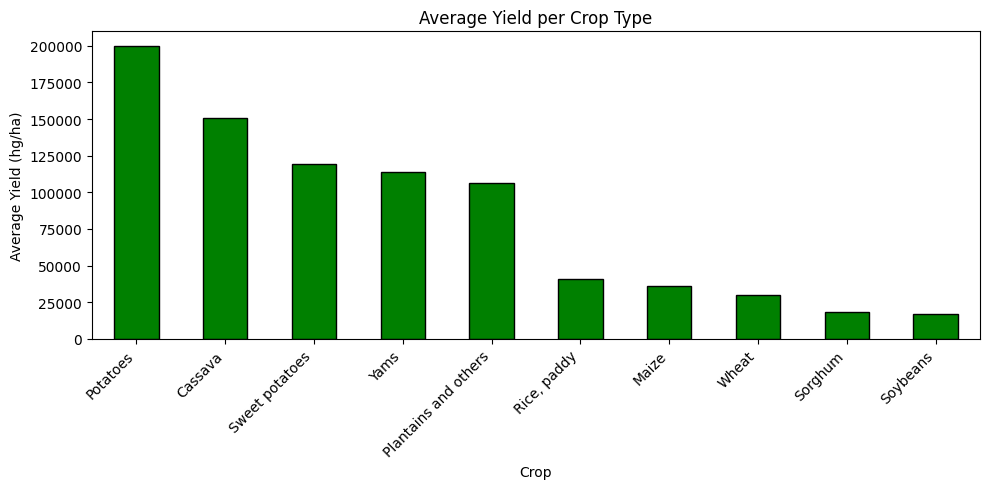

<Figure size 640x480 with 0 Axes>

In [72]:
avg_yield = df.groupby('Item')['hg/ha_yield'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
avg_yield.plot(kind ='bar', color ='green', edgecolor ='black')
plt.xlabel('Crop')
plt.ylabel('Average Yield (hg/ha)')
plt.title('Average Yield per Crop Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.savefig('yield_per_crop.png')

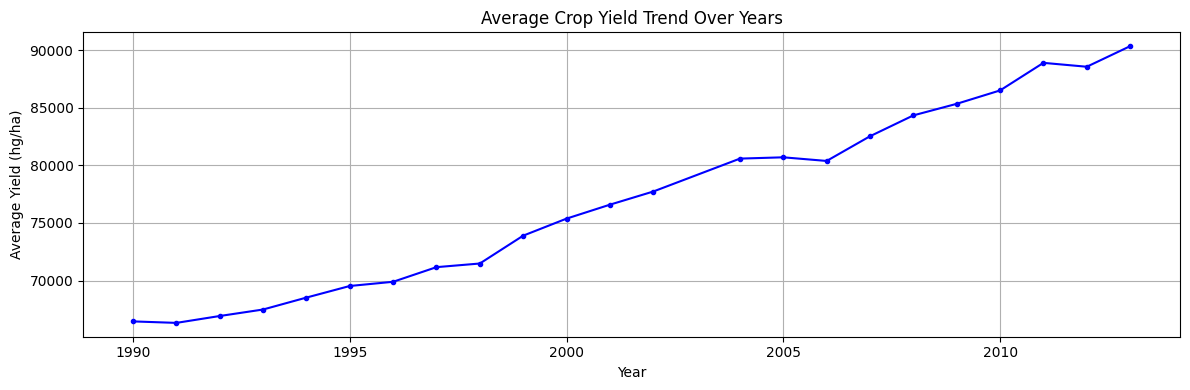

<Figure size 640x480 with 0 Axes>

In [73]:
yield_trend_over_years = df.groupby('Year')['hg/ha_yield'].mean()

plt.figure(figsize=(12, 4))
plt.plot(yield_trend_over_years.index, yield_trend_over_years.values, color='blue', marker='o', markersize=3)
plt.title('Average Crop Yield Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Average Yield (hg/ha)')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig('yield_trend_over_years.png')

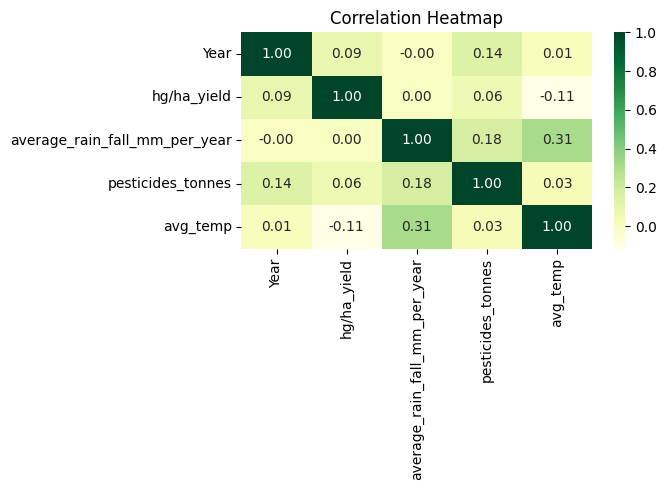

<Figure size 640x480 with 0 Axes>

In [74]:
plt.figure(figsize=(7, 5))
numeric_cols = df.select_dtypes(include='number')
sns.heatmap(numeric_cols.corr(), annot=True, cmap='YlGn', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()
plt.savefig('correlation_heatmap.png')

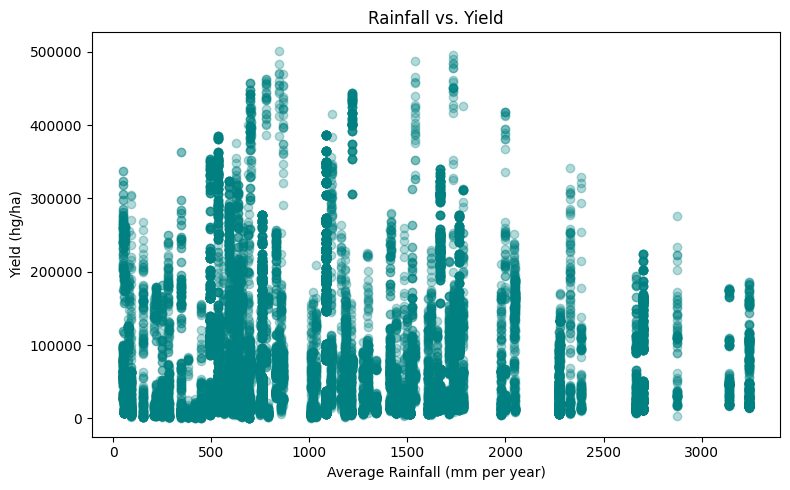

In [75]:
plt.figure(figsize=(8, 5))
plt.scatter(df['average_rain_fall_mm_per_year'], df['hg/ha_yield'], alpha=0.3, color='teal')
plt.xlabel('Average Rainfall (mm per year)')
plt.ylabel('Yield (hg/ha)')
plt.title('Rainfall vs. Yield')
plt.tight_layout()
plt.show()

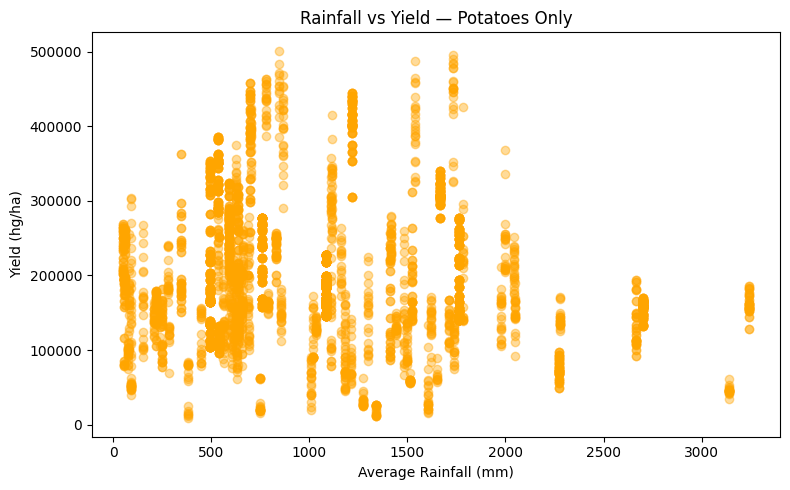

<Figure size 640x480 with 0 Axes>

In [76]:
potatoes = df[df['Item'] == 'Potatoes']

plt.figure(figsize=(8, 5))
plt.scatter(potatoes['average_rain_fall_mm_per_year'], potatoes['hg/ha_yield'], alpha=0.4, color='orange')
plt.title('Rainfall vs Yield — Potatoes Only')
plt.xlabel('Average Rainfall (mm)')
plt.ylabel('Yield (hg/ha)')
plt.tight_layout()
plt.show()
plt.savefig('rainfall_vs_yield_potatoes.png')

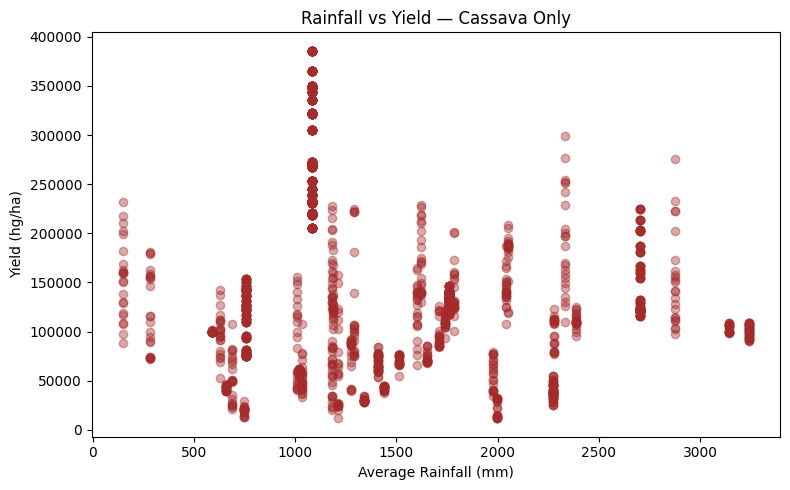

<Figure size 640x480 with 0 Axes>

In [77]:
cassava = df[df['Item'] == 'Cassava']

plt.figure(figsize=(8, 5))
plt.scatter(cassava['average_rain_fall_mm_per_year'], cassava['hg/ha_yield'], alpha=0.4, color='brown')
plt.title('Rainfall vs Yield — Cassava Only')
plt.xlabel('Average Rainfall (mm)')
plt.ylabel('Yield (hg/ha)')
plt.tight_layout()
plt.show()
plt.savefig('rainfall_vs_yield_cassava.png')

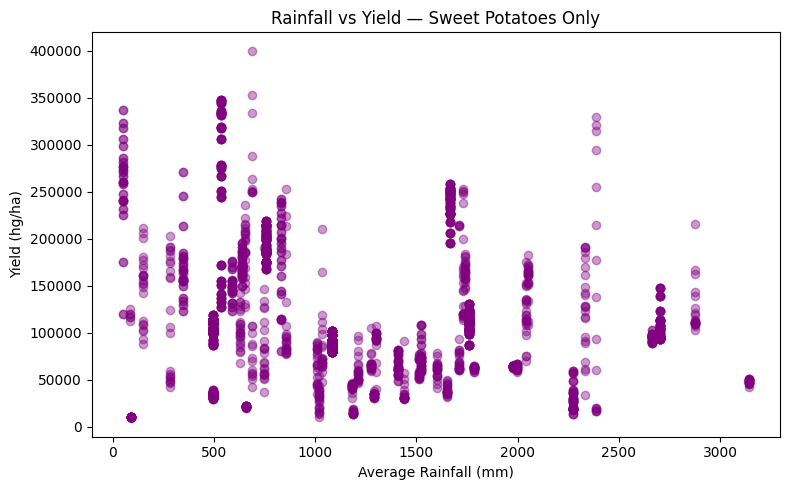

<Figure size 640x480 with 0 Axes>

In [78]:
sweet_potatoes = df[df['Item'] == 'Sweet potatoes']

plt.figure(figsize=(8, 5))
plt.scatter(sweet_potatoes['average_rain_fall_mm_per_year'], sweet_potatoes['hg/ha_yield'], alpha=0.4, color='purple')
plt.title('Rainfall vs Yield — Sweet Potatoes Only')
plt.xlabel('Average Rainfall (mm)')
plt.ylabel('Yield (hg/ha)')
plt.tight_layout()
plt.show()
plt.savefig('rainfall_vs_yield_sweet_potatoes.png')

In [79]:
from sklearn.preprocessing import LabelEncoder

Le_area = LabelEncoder()
Le_item = LabelEncoder()

df['Area_encoded'] = Le_area.fit_transform(df['Area'])
df['Item_encoded'] = Le_item.fit_transform(df['Item'])

features = ['Area_encoded', 'Item_encoded', 'Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
target = 'hg/ha_yield'

X = df[features]
y = df[target]

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')

Features shape: (28242, 6)
Target shape: (28242,)


In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples: {X_test.shape[0]}')

Training samples: 22593
Testing samples: 5649


In [81]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

rmse_ir = np.sqrt(mean_squared_error(y_test, y_pred))
r2_ir = r2_score(y_test, y_pred)

print('Linear Regression')
print(f'RMSE: {rmse_ir:,.2f}')
print(f'R-squared: {r2_ir:4f}')

Linear Regression
RMSE: 81,501.76
R-squared: 0.084252


In [82]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred))
r2_rf = r2_score(y_test, y_pred)

print('Random Forest Regression')
print(f'RMSE: {rmse_rf:,.2f}')
print(f' R-squared: {r2_rf:4f}')


Random Forest Regression
RMSE: 10,181.76
 R-squared: 0.985708


In [83]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [rmse_ir, rmse_rf],
    'R-squared': [r2_ir, r2_rf]
})

results
#

,Model,RMSE,R-squared
0,Linear Regression,81501.764465,0.084252
1,Random Forest,10181.762059,0.985708


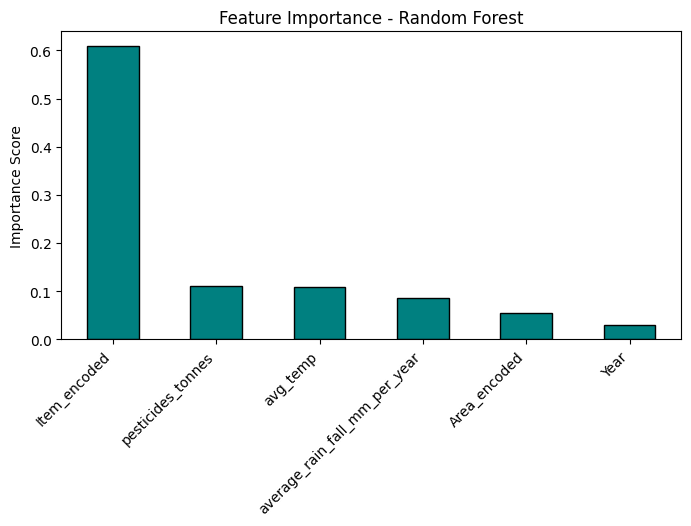

In [84]:
importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
importance.plot(kind='bar', color='teal', edgecolor='black')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.title('Feature Importance - Random Forest')
plt.tight_layout
plt.show
plt.savefig('feature_importance_rf.png')

In [85]:
summary = df.groupby(['Area', 'Item'])['hg/ha_yield'].mean().reset_index()
summary.columns = ['Country', 'Crop', 'Avg_yield_hg/ha']
summary = summary.sort_values('Avg_yield_hg/ha', ascending=False)

summary.to_csv('yield_summary.csv', index=False)
print('Summary saved to outputs/yield_summary.csv')
summary.head(10)

Summary saved to outputs/yield_summary.csv


,Country,Crop,Avg_yield_hg/ha
65,Belgium,Potatoes,448891.538462
410,New Zealand,Potatoes,436177.826087
407,Netherlands,Potatoes,433548.913043
573,United Kingdom,Potatoes,406131.695652
533,Switzerland,Potatoes,400808.913043
186,France,Potatoes,395037.260870
192,Germany,Potatoes,386553.347826
143,Denmark,Potatoes,384700.043478
31,Australia,Potatoes,330944.826087
530,Sweden,Potatoes,315884.000000


### Additional Visualizations and Model Evaluation Outputs

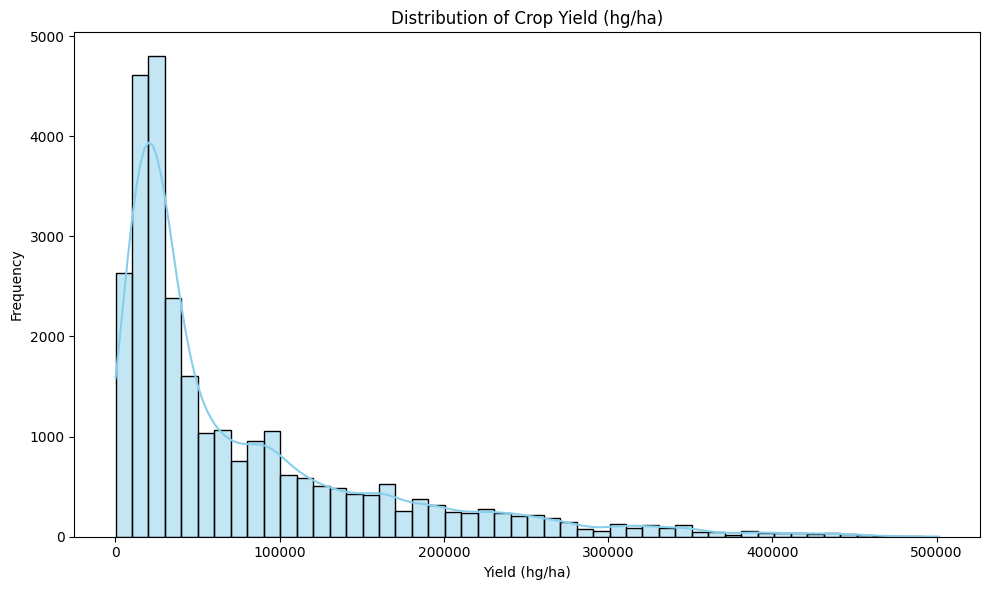

In [87]:
plt.figure(figsize=(10, 6))
sns.histplot(df['hg/ha_yield'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Crop Yield (hg/ha)')
plt.xlabel('Yield (hg/ha)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('yield_distribution.png')
plt.show()

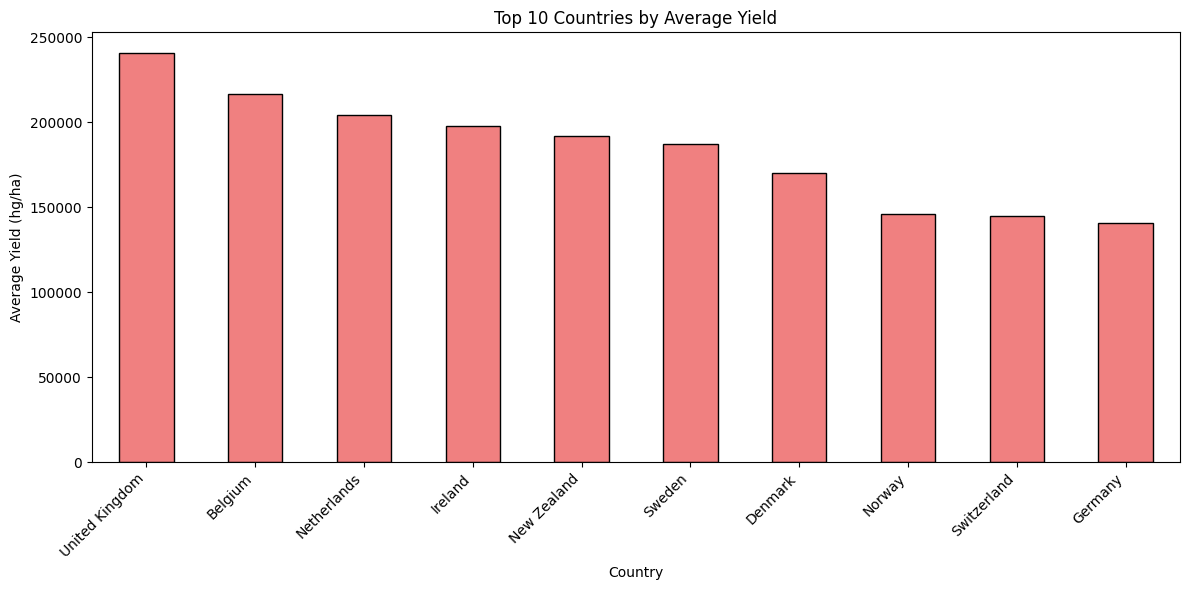

In [88]:
top_10_countries = summary.groupby('Country')['Avg_yield_hg/ha'].mean().nlargest(10)

plt.figure(figsize=(12, 6))
top_10_countries.plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('Top 10 Countries by Average Yield')
plt.xlabel('Country')
plt.ylabel('Average Yield (hg/ha)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_10_countries_by_yield.png')
plt.show()

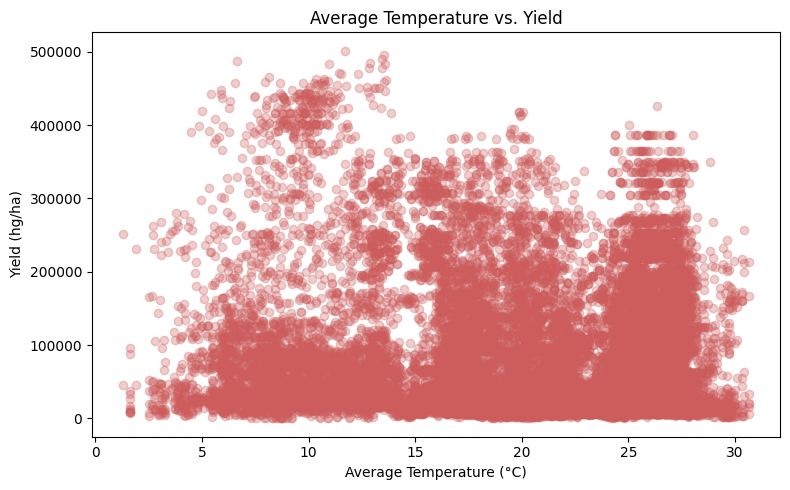

In [89]:
plt.figure(figsize=(8, 5))
plt.scatter(df['avg_temp'], df['hg/ha_yield'], alpha=0.3, color='indianred')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (hg/ha)')
plt.title('Average Temperature vs. Yield')
plt.tight_layout()
plt.savefig('temp_vs_yield.png')
plt.show()

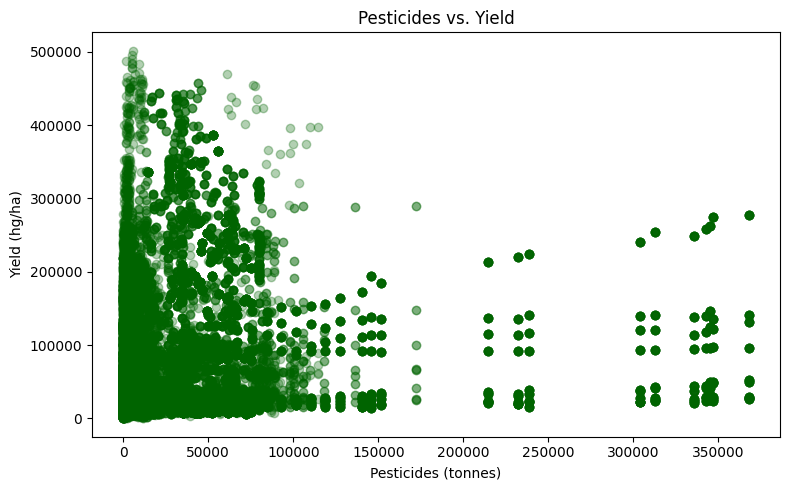

In [90]:
plt.figure(figsize=(8, 5))
plt.scatter(df['pesticides_tonnes'], df['hg/ha_yield'], alpha=0.3, color='darkgreen')
plt.xlabel('Pesticides (tonnes)')
plt.ylabel('Yield (hg/ha)')
plt.title('Pesticides vs. Yield')
plt.tight_layout()
plt.savefig('pesticides_vs_yield.png')
plt.show()

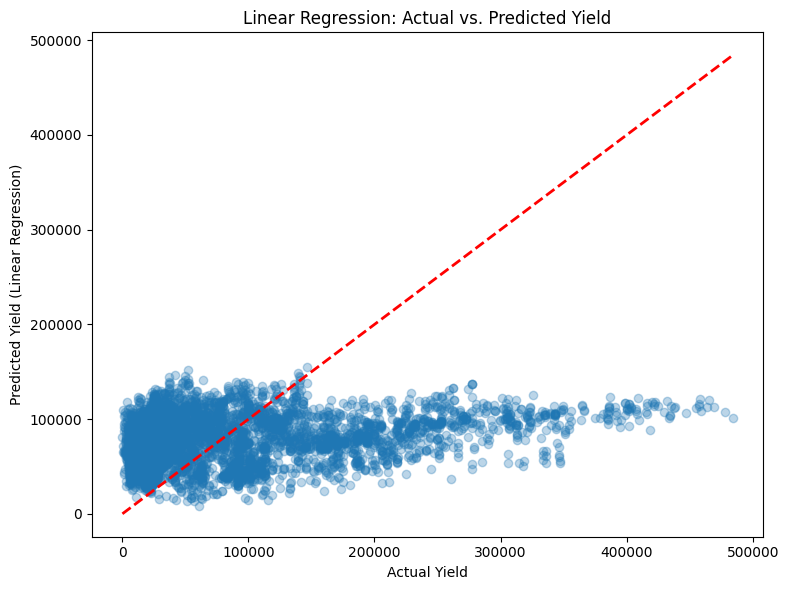

In [91]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, lr.predict(X_test), alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield (Linear Regression)')
plt.title('Linear Regression: Actual vs. Predicted Yield')
plt.tight_layout()
plt.savefig('linear_regression_actual_vs_predicted.png')
plt.show()

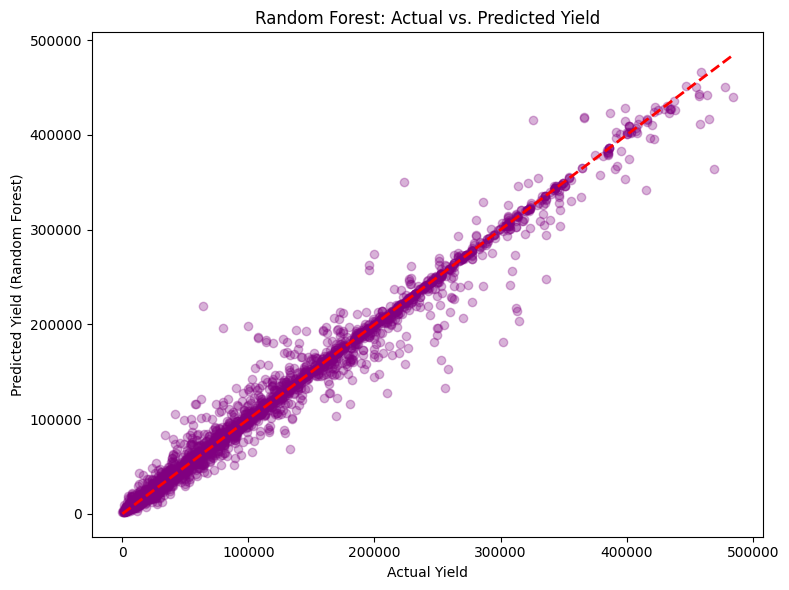

In [92]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf.predict(X_test), alpha=0.3, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield (Random Forest)')
plt.title('Random Forest: Actual vs. Predicted Yield')
plt.tight_layout()
plt.savefig('random_forest_actual_vs_predicted.png')
plt.show()

In [93]:
results.to_csv('model_comparison_table.csv', index=False)
print('Model comparison table saved to model_comparison_table.csv')

Model comparison table saved to model_comparison_table.csv


### Download all requested files

In [94]:
from google.colab import files

files_to_download = [
    'yield_distribution.png',
    'top_10_countries_by_yield.png',
    'yield_per_crop.png',
    'rainfall_vs_yield_potatoes.png',
    'rainfall_vs_yield_cassava.png',
    'rainfall_vs_yield_sweet_potatoes.png',
    'temp_vs_yield.png',
    'pesticides_vs_yield.png',
    'linear_regression_actual_vs_predicted.png',
    'random_forest_actual_vs_predicted.png',
    'feature_importance_rf.png',
    'model_comparison_table.csv',
    'yield_summary.csv'
]

for filename in files_to_download:
    try:
        files.download(filename)
        print(f'Downloaded {filename}')
    except Exception as e:
        print(f'Could not download {filename}: {e}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded yield_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded model_comparison_table.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded yield_summary.csv


In [95]:
from google.colab import files

# Re-downloading just the model comparison table
try:
    files.download('model_comparison_table.csv')
    print('Attempted to re-download model_comparison_table.csv')
except Exception as e:
    print(f'Could not download model_comparison_table.csv: {e}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Attempted to re-download model_comparison_table.csv


In [86]:
!ls -R

.:
 correlation_heatmap.png	       'yield_df[1] (1).csv'
 feature_importance_rf.png	       'yield_df[1] (2).csv'
 rainfall_vs_yield_cassava.png	       'yield_df[1] (3).csv'
 rainfall_vs_yield_maize.png	       'yield_df[1].csv'
 rainfall_vs_yield_potatoes.png         yield_per_crop.png
 rainfall_vs_yield_sweet_potatoes.png   yield_summary.csv
 sample_data			        yield_trend_over_years.png

./sample_data:
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md
